In [24]:
import pandas as pd
import matplotlib.pyplot as plt


## Importing datasets

In [2]:
df_clients = pd.read_csv("../data/raw/clients.csv")
df_products = pd.read_csv('../data/raw/products.csv')
df_stocks = pd.read_csv("../data/raw/stocks.csv")
df_stores = pd.read_csv("../data/raw/stores.csv")
df_transactions = pd.read_csv("../data/raw/transactions.csv")

## Quick checks on duplicates/missing values/etc

In [4]:
df_clients.shape

(424037, 7)

In [10]:
dfs = {
    "clients": df_clients,
    "products": df_products,
    "stocks": df_stocks,
    "stores": df_stores,
    "transactions": df_transactions
}

for name, df in dfs.items():
    print(f"\n=== {name.upper()} DATAFRAME ===")

    duplicates_nb = df.duplicated().sum()
    print(f"The dataframe has {duplicates_nb} duplicated rows among {df.shape[0]} rows")
    if duplicates_nb > 0 :

        df.drop_duplicates(inplace=True)
        print(f"New df has now {df.shape[0]} rows after removing duplicates")

    missing_values = df.isna().sum().sum()
    if missing_values > 0:
        print("Missing values per column:")
        print(df.isna().sum())



=== CLIENTS DATAFRAME ===
The dataframe has 0 duplicated rows among 424037 rows
Missing values per column:
ClientID                 0
ClientSegment            0
ClientCountry            0
ClientOptINEmail         0
ClientOptINPhone         0
ClientGender         60795
Age                 304075
dtype: int64

=== PRODUCTS DATAFRAME ===
The dataframe has 0 duplicated rows among 47458 rows

=== STOCKS DATAFRAME ===
The dataframe has 0 duplicated rows among 16024 rows

=== STORES DATAFRAME ===
The dataframe has 0 duplicated rows among 606 rows

=== TRANSACTIONS DATAFRAME ===
The dataframe has 5121 duplicated rows among 1177175 rows
New df has now 1172054 rows after removing duplicates


Too many missing value in the column age of df_clients, let's get rid of this. Regarding Client Gender, for now we will replace the missing values with "Unkown"

In [11]:
df_clients.drop(columns = "Age", inplace=True)

In [12]:
df_clients["ClientGender"].value_counts()

ClientGender
F    239669
M    122210
C       945
N       216
U       202
Name: count, dtype: int64

In [15]:
df_clients["ClientGender"] = df_clients["ClientGender"].fillna("N/A")

## First visuals insights

### Focus on df_clients

In [16]:
df_clients.head()

,ClientID,ClientSegment,ClientCountry,ClientOptINEmail,ClientOptINPhone,ClientGender
0,4508698145640552159,LOYAL,USA,1,1,M
1,2022746661324934183,INACTIVE_1Y,USA,0,1,F
2,5794452591674300222,LOYAL,USA,1,1,F
3,678556389231830160,LOYAL,USA,1,1,M
4,877301557964624234,LOYAL,USA,1,1,F


In [22]:
df_clients.groupby("ClientCountry").agg(customers_count=("ClientCountry", "count")).sort_values("customers_count", ascending = False).reset_index()

,ClientCountry,customers_count
0,USA,219056
1,FRA,62444
2,GBR,59116
3,AUS,30456
4,DEU,29242
5,ARE,18492
6,BRA,5231


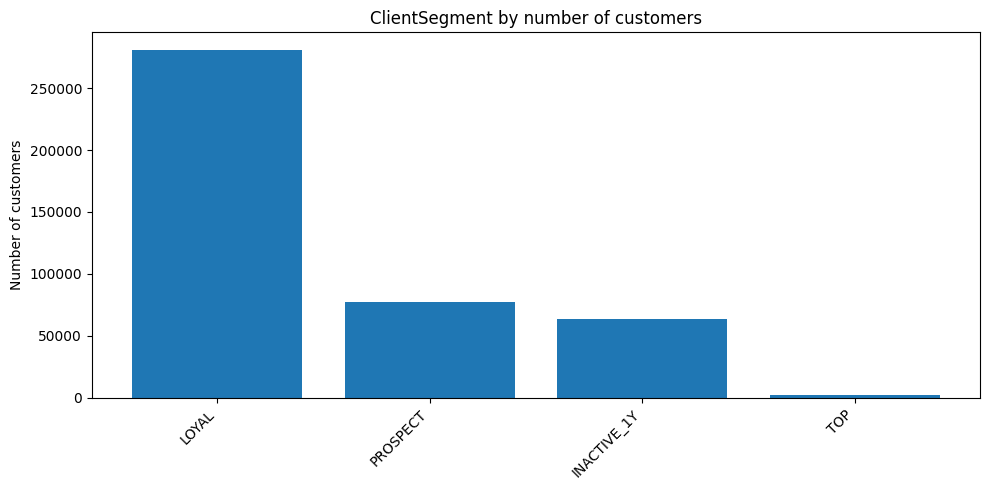

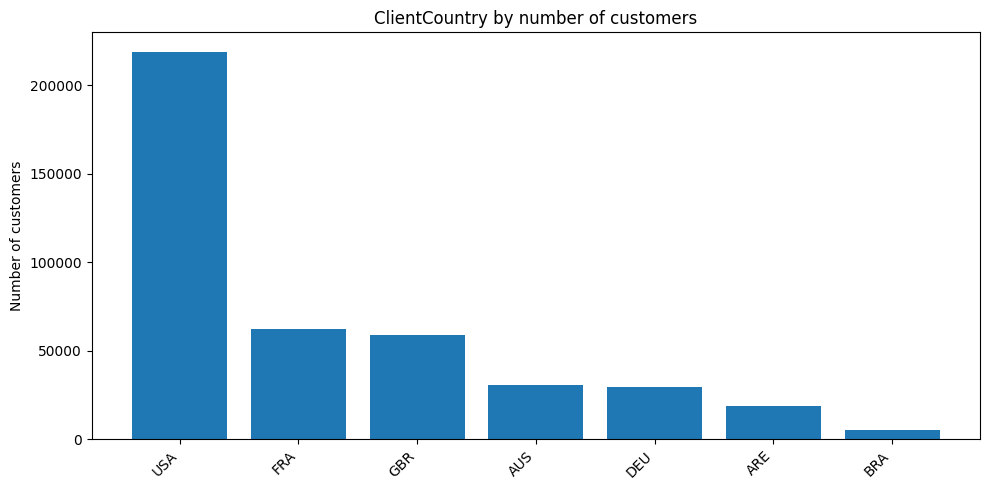

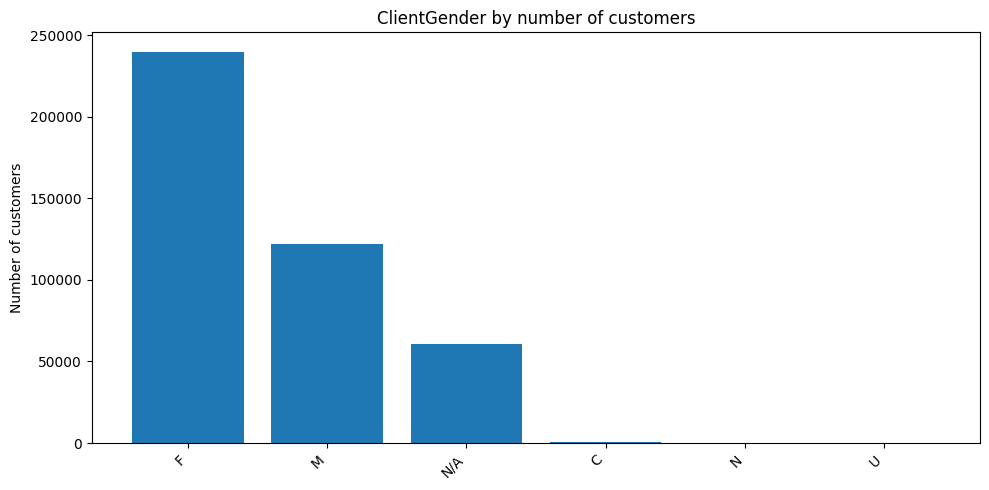

In [25]:
top_n = 15
for col in ["ClientSegment", "ClientCountry", "ClientGender"]:
    plot_df = df_clients.groupby(col).agg(customers_count=(col, "count")).sort_values("customers_count", ascending = False).reset_index().head(top_n)

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df[col], plot_df["customers_count"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of customers")
    plt.title(f"{col} by number of customers")
    plt.tight_layout()
    plt.show()
